# 1.4 — Augmentation des données

Les augmentations sont visualisées ici (avant/après). Les paramètres exacts seront définis lors du choix du modèle (section 2.1).

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

DATASET_ROOT = Path(r"C:\Users\luigi\OneDrive\Documents\Ecole 18.06\Traitement_image\Projet\SH17dataset")

random.seed(14)
img_path = random.choice(list((DATASET_ROOT / 'images' / 'train').glob('*.*')))
ORIGINAL  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

def show_grid(images, titles, suptitle, figsize=(16, 4)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"Image de reference : {img_path.name}  {ORIGINAL.shape[1]}x{ORIGINAL.shape[0]}px")

Image de reference : pexels-photo-2880872.jpeg  4586x3058px


## 1. Variations d'éclairage

Sur un chantier, les conditions lumineuses varient fortement : soleil de face (contre-jour), éblouissement de réflecteurs, travaux nocturnes. Ces augmentations forcent le modèle à détecter les EPI quelle que soit la luminosité.

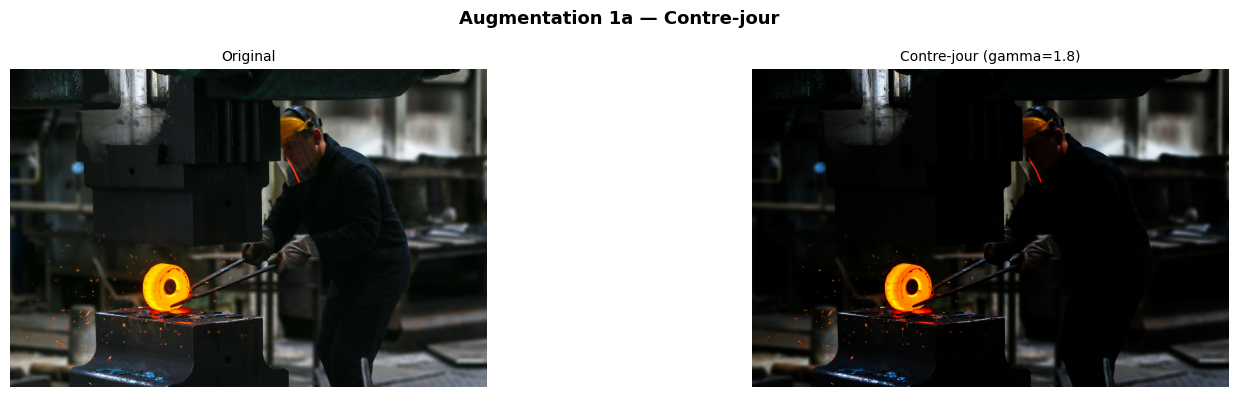

In [31]:
def gamma(img, g):
    table = np.array([((i / 255.0) ** g) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img, table)

contrejour = gamma(ORIGINAL, 1.8)

show_grid(
    [ORIGINAL, contrejour],
    ['Original', 'Contre-jour (gamma=1.8)'],
    'Augmentation 1a — Contre-jour'
)

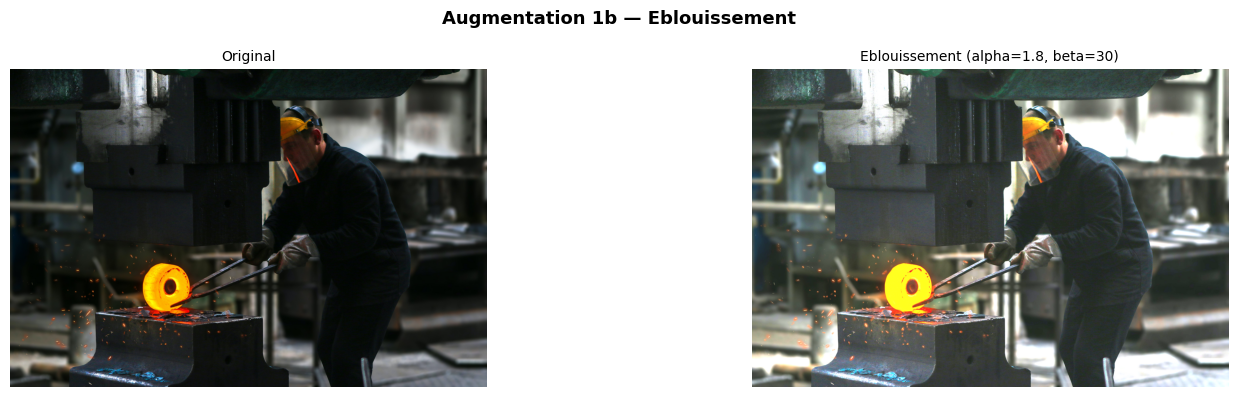

In [32]:
def eblouissement(img, alpha=1.8, beta=30):
    return np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

ebloui = eblouissement(ORIGINAL)

show_grid(
    [ORIGINAL, ebloui],
    ['Original', 'Eblouissement (alpha=1.8, beta=30)'],
    'Augmentation 1b — Eblouissement'
)

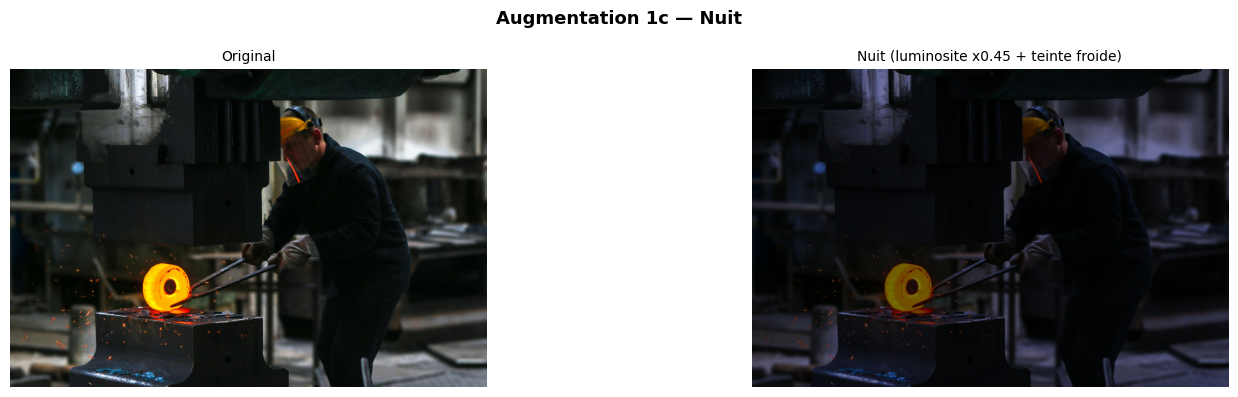

In [33]:
def nuit(img):
    dark = np.clip(img.astype(np.float32) * 0.45, 0, 255).astype(np.uint8)
    dark_bgr = cv2.cvtColor(dark, cv2.COLOR_RGB2BGR)
    dark_bgr[:, :, 0] = np.clip(dark_bgr[:, :, 0].astype(np.float32) * 1.4, 0, 255)
    return cv2.cvtColor(dark_bgr, cv2.COLOR_BGR2RGB)

nocturne = nuit(ORIGINAL)

show_grid(
    [ORIGINAL, nocturne],
    ['Original', 'Nuit (luminosite x0.45 + teinte froide)'],
    'Augmentation 1c — Nuit'
)

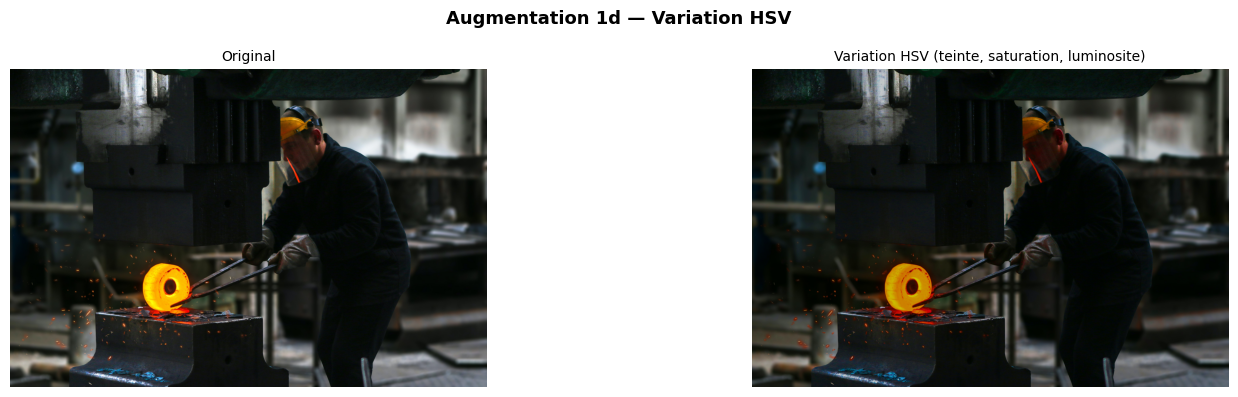

In [34]:
def hsv_jitter(img, dh=0.015, ds=0.7, dv=0.4):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:, :, 0] = (hsv[:, :, 0] + dh * 180 * (2 * np.random.rand() - 1)) % 180
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * (1 + ds * (2 * np.random.rand() - 1)), 0, 255)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * (1 + dv * (2 * np.random.rand() - 1)), 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

np.random.seed(12)
hsv_aug = hsv_jitter(ORIGINAL)

show_grid(
    [ORIGINAL, hsv_aug],
    ['Original', 'Variation HSV (teinte, saturation, luminosite)'],
    'Augmentation 1d — Variation HSV'
)

## 2. Changements d'angle de vue

Les caméras sur chantier sont rarement placées à hauteur d'yeux : perchées sur des mâts, inclinées sur des véhicules, ou portées à bout de bras. Ces augmentations simulent ces angles non standards.

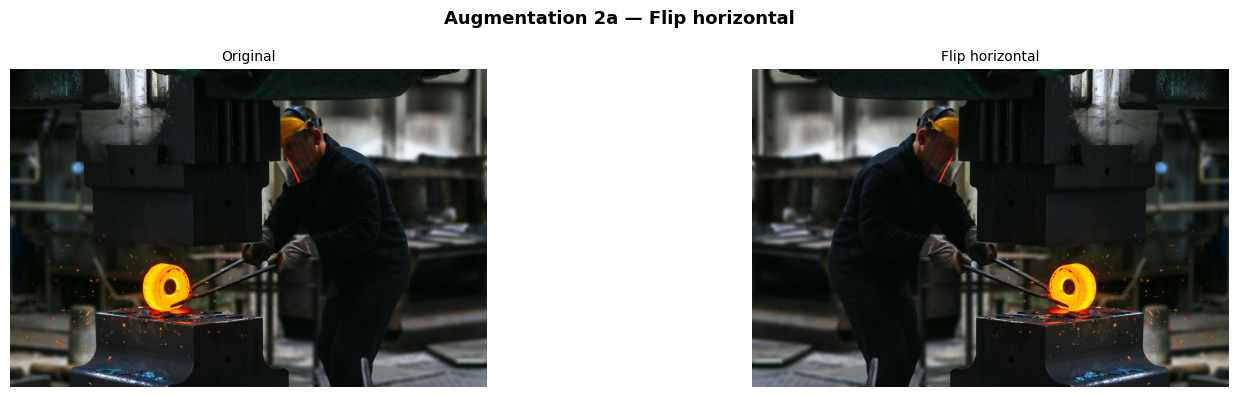

In [35]:
flip = cv2.flip(ORIGINAL, 1)

show_grid(
    [ORIGINAL, flip],
    ['Original', 'Flip horizontal'],
    'Augmentation 2a — Flip horizontal'
)

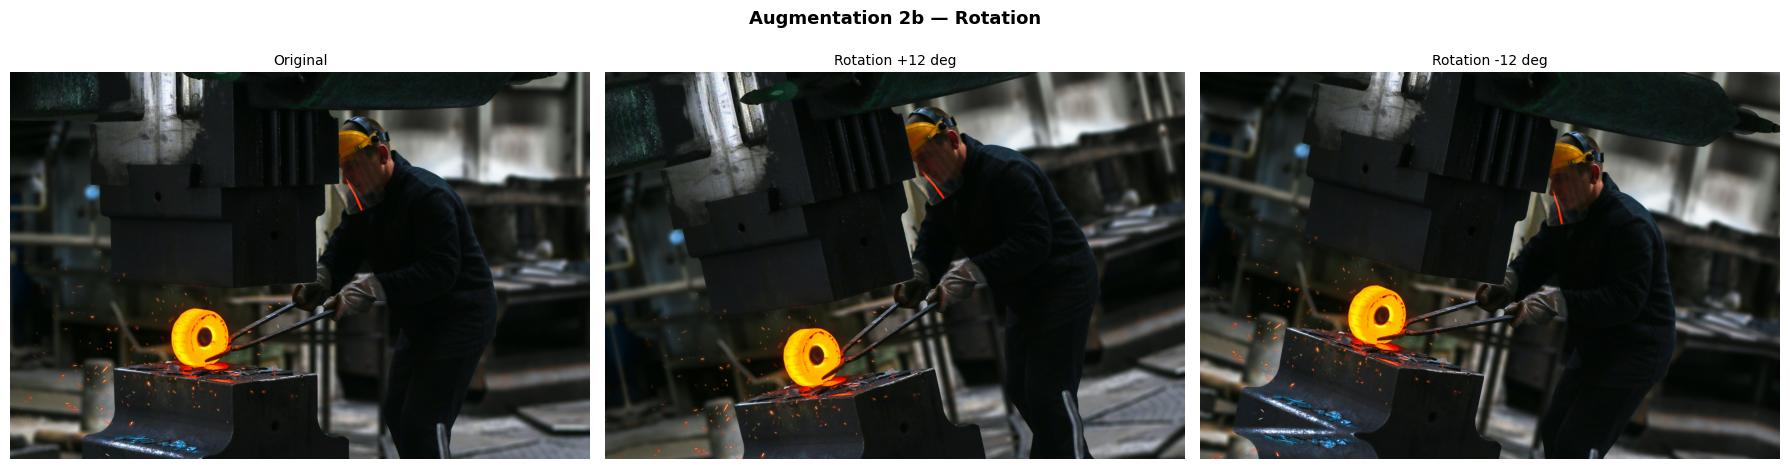

In [36]:
def rotation(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

rot_pos = rotation(ORIGINAL,  12)
rot_neg = rotation(ORIGINAL, -12)

show_grid(
    [ORIGINAL, rot_pos, rot_neg],
    ['Original', 'Rotation +12 deg', 'Rotation -12 deg'],
    'Augmentation 2b — Rotation',
    figsize=(18, 5)
)

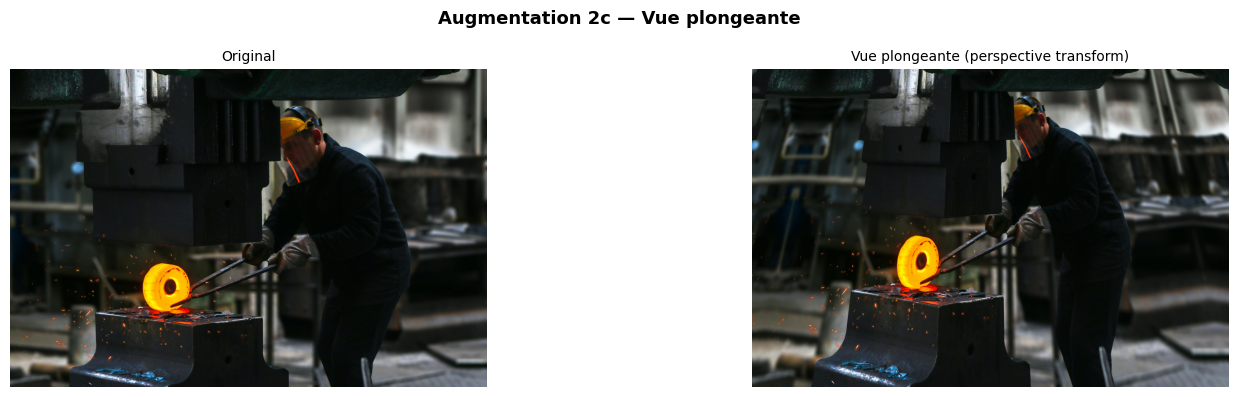

In [37]:
def vue_plongeante(img, strength=0.15):
    h, w = img.shape[:2]
    d = int(w * strength)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst = np.float32([[d, 0], [w - d, 0], [w, h], [0, h]])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

plongeant = vue_plongeante(ORIGINAL)

show_grid(
    [ORIGINAL, plongeant],
    ['Original', 'Vue plongeante (perspective transform)'],
    'Augmentation 2c — Vue plongeante'
)

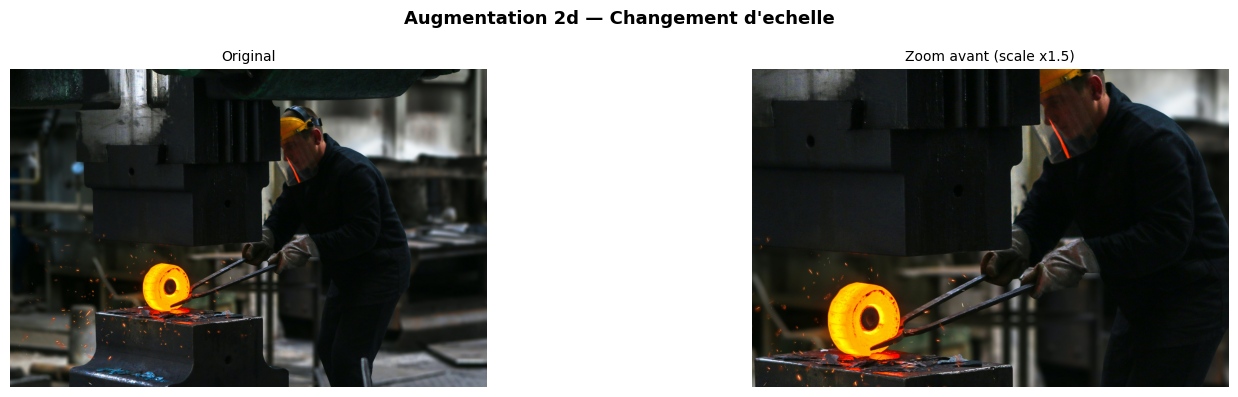

In [38]:
def scale_crop(img, factor=0.7):
    h, w = img.shape[:2]
    nh, nw = int(h * factor), int(w * factor)
    y0 = (h - nh) // 2
    x0 = (w - nw) // 2
    crop = img[y0:y0+nh, x0:x0+nw]
    return cv2.resize(crop, (w, h))

zoomed = scale_crop(ORIGINAL, 0.65)

show_grid(
    [ORIGINAL, zoomed],
    ['Original', 'Zoom avant (scale x1.5)'],
    'Augmentation 2d — Changement d\'echelle'
)

## 3. Occlusions partielles

Sur un chantier, les ouvriers sont fréquemment partiellement cachés : par une machine, un autre ouvrier, un élément de structure. Le modèle doit apprendre à détecter un casque ou un gilet même quand une partie de la personne est masquée.

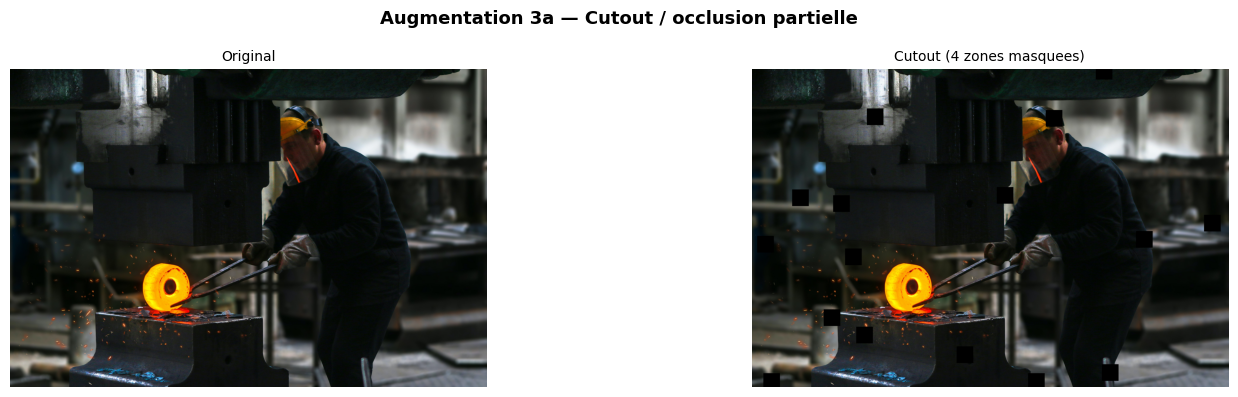

In [39]:
def cutout(img, n_holes=16, hole_size=160):
    img = img.copy()
    h, w = img.shape[:2]
    np.random.seed(42)
    for _ in range(n_holes):
        cx = np.random.randint(0, w)
        cy = np.random.randint(0, h)
        x1, x2 = max(0, cx - hole_size // 2), min(w, cx + hole_size // 2)
        y1, y2 = max(0, cy - hole_size // 2), min(h, cy + hole_size // 2)
        img[y1:y2, x1:x2] = 0
    return img

cutout_img = cutout(ORIGINAL)

show_grid(
    [ORIGINAL, cutout_img],
    ['Original', 'Cutout (4 zones masquees)'],
    'Augmentation 3a — Cutout / occlusion partielle'
)

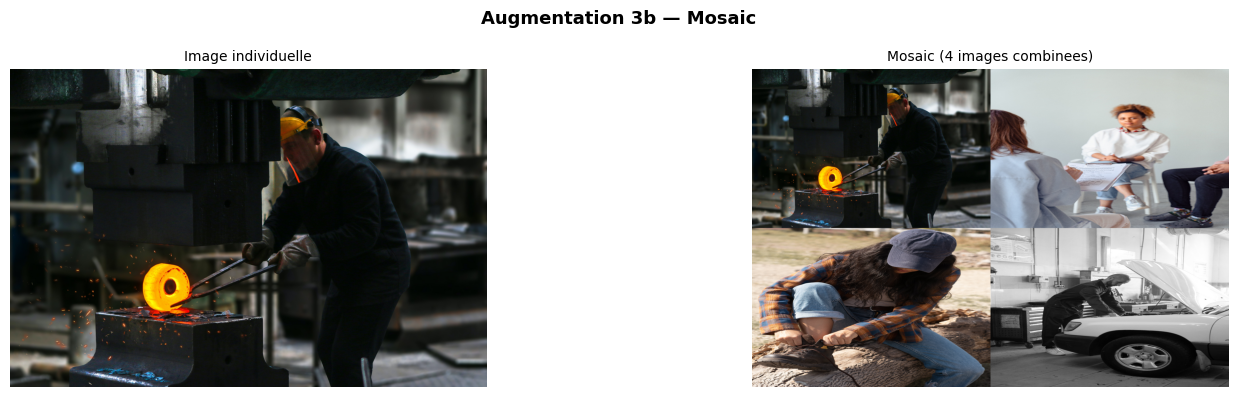

In [40]:
def mosaic_simulation(imgs):
    h, w = imgs[0].shape[:2]
    th, tw = h // 2, w // 2
    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    canvas[:th, :tw]  = cv2.resize(imgs[0], (tw, th))
    canvas[:th, tw:]  = cv2.resize(imgs[1], (w - tw, th))
    canvas[th:, :tw]  = cv2.resize(imgs[2], (tw, h - th))
    canvas[th:, tw:]  = cv2.resize(imgs[3], (w - tw, h - th))
    return canvas

np.random.seed(5)

all_imgs     = list((DATASET_ROOT / 'images' / 'train').glob('*.*'))
sample_paths = random.sample(all_imgs, 3)
sample_imgs  = [ORIGINAL] + [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) for p in sample_paths]
mosaic_img   = mosaic_simulation(sample_imgs)


show_grid(
    [ORIGINAL, mosaic_img],
    ['Image individuelle', 'Mosaic (4 images combinees)'],
    'Augmentation 3b — Mosaic'
)

## Récapitulatif des augmentations

Les paramètres exacts seront définis lors du choix du modèle (section 2.1).

| Augmentation | Paramètres visualisation |
|---|---|
| Contre-jour | gamma=1.8 |
| Éblouissement | alpha=1.8, beta=30 |
| Nuit | x0.45, teinte froide x1.4 |
| Variation HSV | dh=0.015, ds=0.7, dv=0.4 |
| Flip horizontal | probabilité 0.5 |
| Rotation | ±12° (amplitude max ±15°) |
| Vue plongeante | strength=0.15 |
| Changement d'échelle | factor=0.65 |
| Translation | ±10% |
| Cutout | n_holes=16, size=160 |
| Mosaic | 4 images combinées |